# A1 Coursework

## Question 1: Likelihood based analysis of the 21-cm power spectrum

### (a) PCA

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd()
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from apb86_a1 import (
    TrainingConfig,
    build_emulator,
    cumulative_explained_variance,
    fit_pca_with_observation,
    load_observations,
    load_simulation_dataset,
    normalize_observation,
    normalize_spectra,
    optimize_emulator,
    save_observations_pca,
    save_pca_model,
    save_split_datasets,
    split_training_data,
    test_emulator,
    train_emulator,
    )

# Load the data
data_path = "data"
observations = load_observations(data_path)
simulations = load_simulation_dataset(data_path)

observations_spectrum = observations.power
observations_ks = observations.k
ks = simulations.ks
spectra = simulations.spectra
params = simulations.params
redshift = simulations.redshift
code = simulations.code
code_version = simulations.code_version

/home/alex/projects/a1_coursework/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[0.00166234 0.00187171 0.00210745 0.00237288 0.00267174 0.00300824
 0.00338713 0.00381373 0.00429407 0.0048349  0.00544385 0.00612949
 0.0069015  0.00777073 0.00874945 0.00985143 0.0110922  0.01248925
 0.01406226 0.01583338 0.01782758 0.02007294 0.0226011  0.02544768
 0.02865278 0.03226156 0.03632487 0.04089994 0.04605123 0.05185133
 0.05838194 0.06573507 0.07401432 0.08333633 0.09383244 0.10565052
 0.11895707 0.13393956 0.15080909 0.1698033  0.19118982 0.21526993
 0.24238291 0.27291074 0.30728351 0.34598548 0.38956192 0.43862676
 0.49387125 0.55607372 0.62611051 0.70496834 0.79375823 0.89373108]
('k', 'power', 'astro_params', 'cosmo_params', 'redshfit', 'code', 'code_version')
Training set size: 7997
Validation set size: 1000
Test set size: 1000
Min power (from training): 6.303388878614356e-07
Max power (from training): 640.3159675853942


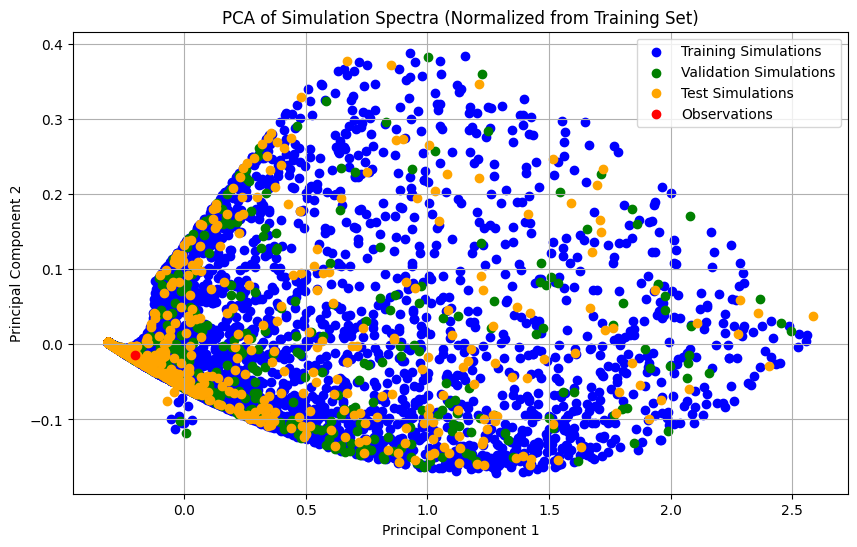

In [2]:
print(observations_ks)
print(("k", "power", "astro_params", "cosmo_params", "redshfit", "code", "code_version"))

# Split the data BEFORE normalization into training, validation, and test sets with 80-10-10 split
splits = split_training_data(
    params,
    spectra,
    train_fraction=0.8,
    val_fraction=0.1,
    test_fraction=0.1,
    random_state=42,
)
spectra_train = splits.y_train
spectra_val = splits.y_val
spectra_test = splits.y_test
params_train = splits.x_train
params_val = splits.x_val
params_test = splits.x_test

print(f"Training set size: {spectra_train.shape[0]}")
print(f"Validation set size: {spectra_val.shape[0]}")
print(f"Test set size: {spectra_test.shape[0]}")

# Compute normalization statistics from training set only
normalized_spectra_train, normalization_stats = normalize_spectra(spectra_train)
# Apply the same normalization to validation and test sets
normalized_spectra_val, _ = normalize_spectra(spectra_val, stats=normalization_stats)
normalized_spectra_test, _ = normalize_spectra(spectra_test, stats=normalization_stats)

# Normalize the observation spectrum using training set statistics
normalized_observations_spectrum = normalize_observation(
    observations_spectrum, normalization_stats
)

max_power = normalization_stats.max_power
min_power = normalization_stats.min_power
print(f"Min power (from training): {min_power}")
print(f"Max power (from training): {max_power}")

# Fit PCA on normalized training spectra (combined with observation for projection space)
pca_results = fit_pca_with_observation(
    normalized_spectra_train,
    normalized_observations_spectrum,
    n_components=2,
)
pca_2 = pca_results.pca_model
pca_2_observations_result = pca_results.observation_components
pca_2_simulations_spectra_train = pca_results.simulation_components

# Transform validation and test sets using the fitted PCA model
pca_2_simulations_spectra_val = pca_2.transform(normalized_spectra_val)
pca_2_simulations_spectra_test = pca_2.transform(normalized_spectra_test)

plt.figure(figsize=(10, 6))
plt.scatter(pca_2_simulations_spectra_train[:, 0], pca_2_simulations_spectra_train[:, 1], c='blue', label='Training Simulations')
plt.scatter(pca_2_simulations_spectra_val[:, 0], pca_2_simulations_spectra_val[:, 1], c='green', label='Validation Simulations')
plt.scatter(pca_2_simulations_spectra_test[:, 0], pca_2_simulations_spectra_test[:, 1], c='orange', label='Test Simulations')
plt.scatter(pca_2_observations_result[:, 0], pca_2_observations_result[:, 1], c='red', label='Observations')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Simulation Spectra (Normalized from Training Set)')
plt.legend()
plt.grid()
plt.show()


In [3]:
from sklearn.decomposition import PCA

# Fit PCA with 54 components on the training set only
pca_54 = PCA(n_components=54)
pca_54.fit(normalized_spectra_train)
pca_54_result = pca_54.transform(normalized_spectra_train)

print(f"PCA 54 components shape: {pca_54_result.shape}")
print(f"Explained variance ratio: {pca_54.explained_variance_ratio_[:10]}")
print(f"Cumulative explained variance: {cumulative_explained_variance(pca_54)}")


PCA 54 components shape: (7997, 54)
Explained variance ratio: [9.83595420e-01 1.60578516e-02 3.08981448e-04 3.76838811e-05
 5.33825784e-08 9.18437075e-09 1.56757807e-10 9.80806930e-11
 2.67764883e-11 2.37934409e-11]
Cumulative explained variance: [0.98359542 0.99965327 0.99996225 0.99999994 0.99999999 1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.        ]


[0.00166234 0.00187171 0.00210745 0.00237288 0.00267174 0.00300824
 0.00338713 0.00381373 0.00429407 0.0048349  0.00544385 0.00612949
 0.0069015  0.00777073 0.00874945 0.00985143 0.0110922  0.01248925
 0.01406226 0.01583338 0.01782758 0.02007294 0.0226011  0.02544768
 0.02865278 0.03226156 0.03632487 0.04089994 0.04605123 0.05185133
 0.05838194 0.06573507 0.07401432 0.08333633 0.09383244 0.10565052
 0.11895707 0.13393956 0.15080909 0.1698033  0.19118982 0.21526993
 0.24238291 0.27291074 0.30728351 0.34598548 0.38956192 0.43862676
 0.49387125 0.55607372 0.62611051 0.70496834 0.79375823 0.89373108]


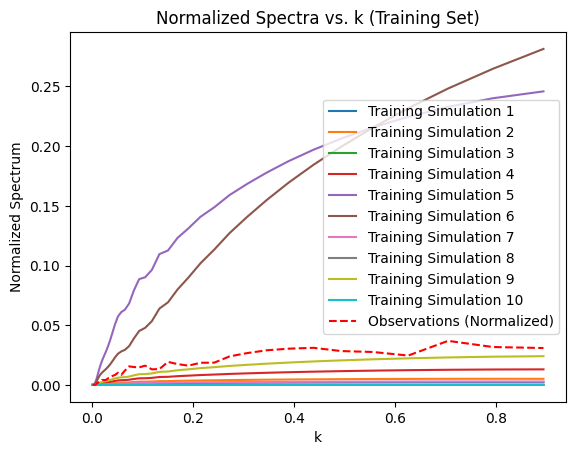

In [4]:
print(ks[0])

# Plot a sample of normalized spectra from the training set
for i in range(min(10, len(normalized_spectra_train))):
    plt.plot(ks[i], normalized_spectra_train[i], label=f"Training Simulation {i+1}")

plt.plot(observations_ks, normalized_observations_spectrum, label="Observations (Normalized)", linestyle='dashed', color='red')

plt.xlabel("k")
plt.ylabel("Normalized Spectrum")
plt.title("Normalized Spectra vs. k (Training Set)")
plt.legend()
plt.show()


We use 2 principal components, which together explain $>99.96\%$ of the variance in the data. We now split the normalised and decomposed simulations into training, validation, and testing samples using an 80:10:10 split. We also apply the same normalisation and PCA reduction to the observed power spectrum.

In [5]:
# Prepare training, validation, and test sets for the neural network
# (using parameters as inputs and PCA-reduced spectra as outputs)
X_train = params_train
X_val = params_val
X_test = params_test
y_train = pca_2_simulations_spectra_train
y_val = pca_2_simulations_spectra_val
y_test = pca_2_simulations_spectra_test

print(f"Training set: X={X_train.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val.shape}, y={y_val.shape}")
print(f"Test set: X={X_test.shape}, y={y_test.shape}")

# Save preprocessing artifacts
save_split_datasets(
    data_path,
    x_train=X_train,
    y_train=y_train,
    x_val=X_val,
    y_val=y_val,
    x_test=X_test,
    y_test=y_test,
)
save_observations_pca(Path(data_path) / "observations_pca.npz", pca_2_observations_result)
save_pca_model(Path(data_path) / "pca_model.pkl", pca_2)


Training set: X=(7997, 4), y=(7997, 2)
Validation set: X=(1000, 4), y=(1000, 2)
Test set: X=(1000, 4), y=(1000, 2)


### (b)

The data is normalised by subtracting the minimum power in the simulations and dividing by the difference between the maximum power and the minimum power in the simulations.

In [6]:
training_config = TrainingConfig(epochs=200, validation_interval=10)
model = build_emulator(hidden_units=training_config.hidden_units, device=training_config.device)
history = train_emulator(
    model,
    X_train,
    y_train,
    x_val=X_val,
    y_val=y_val,
    config=training_config,
 )

for epoch_number, val_loss in zip(
    range(
        training_config.validation_interval,
        training_config.epochs + 1,
        training_config.validation_interval,
    ),
    history.val_loss,
 ):
    train_loss = history.train_loss[epoch_number - 1]
    print(
        f"Epoch [{epoch_number}/{training_config.epochs}], "
        f"Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}"
    )

evaluation = test_emulator(model, X_test, y_test)
print(f"Test MSE: {evaluation.mse:.4f}")

Epoch [10/200], Loss: 0.1322, Validation Loss: 0.1230
Epoch [20/200], Loss: 0.0978, Validation Loss: 0.0894
Epoch [30/200], Loss: 0.0496, Validation Loss: 0.0430
Epoch [40/200], Loss: 0.0181, Validation Loss: 0.0151
Epoch [50/200], Loss: 0.0127, Validation Loss: 0.0109
Epoch [60/200], Loss: 0.0093, Validation Loss: 0.0089
Epoch [70/200], Loss: 0.0073, Validation Loss: 0.0071
Epoch [80/200], Loss: 0.0059, Validation Loss: 0.0059
Epoch [90/200], Loss: 0.0049, Validation Loss: 0.0048
Epoch [100/200], Loss: 0.0039, Validation Loss: 0.0038
Epoch [110/200], Loss: 0.0031, Validation Loss: 0.0030
Epoch [120/200], Loss: 0.0025, Validation Loss: 0.0026
Epoch [130/200], Loss: 0.0020, Validation Loss: 0.0020
Epoch [140/200], Loss: 0.0016, Validation Loss: 0.0016
Epoch [150/200], Loss: 0.0013, Validation Loss: 0.0013
Epoch [160/200], Loss: 0.0011, Validation Loss: 0.0011
Epoch [170/200], Loss: 0.0010, Validation Loss: 0.0010
Epoch [180/200], Loss: 0.0012, Validation Loss: 0.0010
Epoch [190/200], Lo

[I 2026-03-17 20:00:57,686] A new study created in memory with name: no-name-a3f3748e-ab5c-4386-80ef-333329852258
[I 2026-03-17 20:01:19,937] Trial 0 finished with value: 0.007299934979528189 and parameters: {'n_hidden_layers': 4, 'n_hidden_units_1': 32, 'n_hidden_units_2': 128, 'n_hidden_units_3': 16, 'n_hidden_units_4': 256, 'dropout_rate_1': 0.48213096222273066, 'dropout_rate_2': 0.4195983878407788, 'dropout_rate_3': 0.09844120231572212, 'dropout_rate_4': 0.40905770910839134, 'optimizer_name': 'adam', 'learning_rate': 0.0006366494513978552}. Best is trial 0 with value: 0.007299934979528189.
[I 2026-03-17 20:01:27,563] Trial 1 finished with value: 0.014789565466344357 and parameters: {'n_hidden_layers': 2, 'n_hidden_units_1': 128, 'n_hidden_units_2': 64, 'dropout_rate_1': 0.44822241096882837, 'dropout_rate_2': 0.18833652956144176, 'optimizer_name': 'rmsprop', 'learning_rate': 0.009997222555048035}. Best is trial 0 with value: 0.007299934979528189.
[I 2026-03-17 20:01:34,521] Trial 2 

Best hyperparameters:  {'n_hidden_layers': 4, 'n_hidden_units_1': 256, 'n_hidden_units_2': 128, 'n_hidden_units_3': 256, 'n_hidden_units_4': 256, 'dropout_rate_1': 0.013141891821632782, 'dropout_rate_2': 0.3459434176106936, 'dropout_rate_3': 0.3520137771771259, 'dropout_rate_4': 0.39595931929446904, 'optimizer_name': 'adamw', 'learning_rate': 0.0011125884672872396}
Best validation loss:  0.00042853516060858965
Best optimized model saved to: data/best_optimized_model.pt
Optimization curves saved to: data/optimization_curves.png


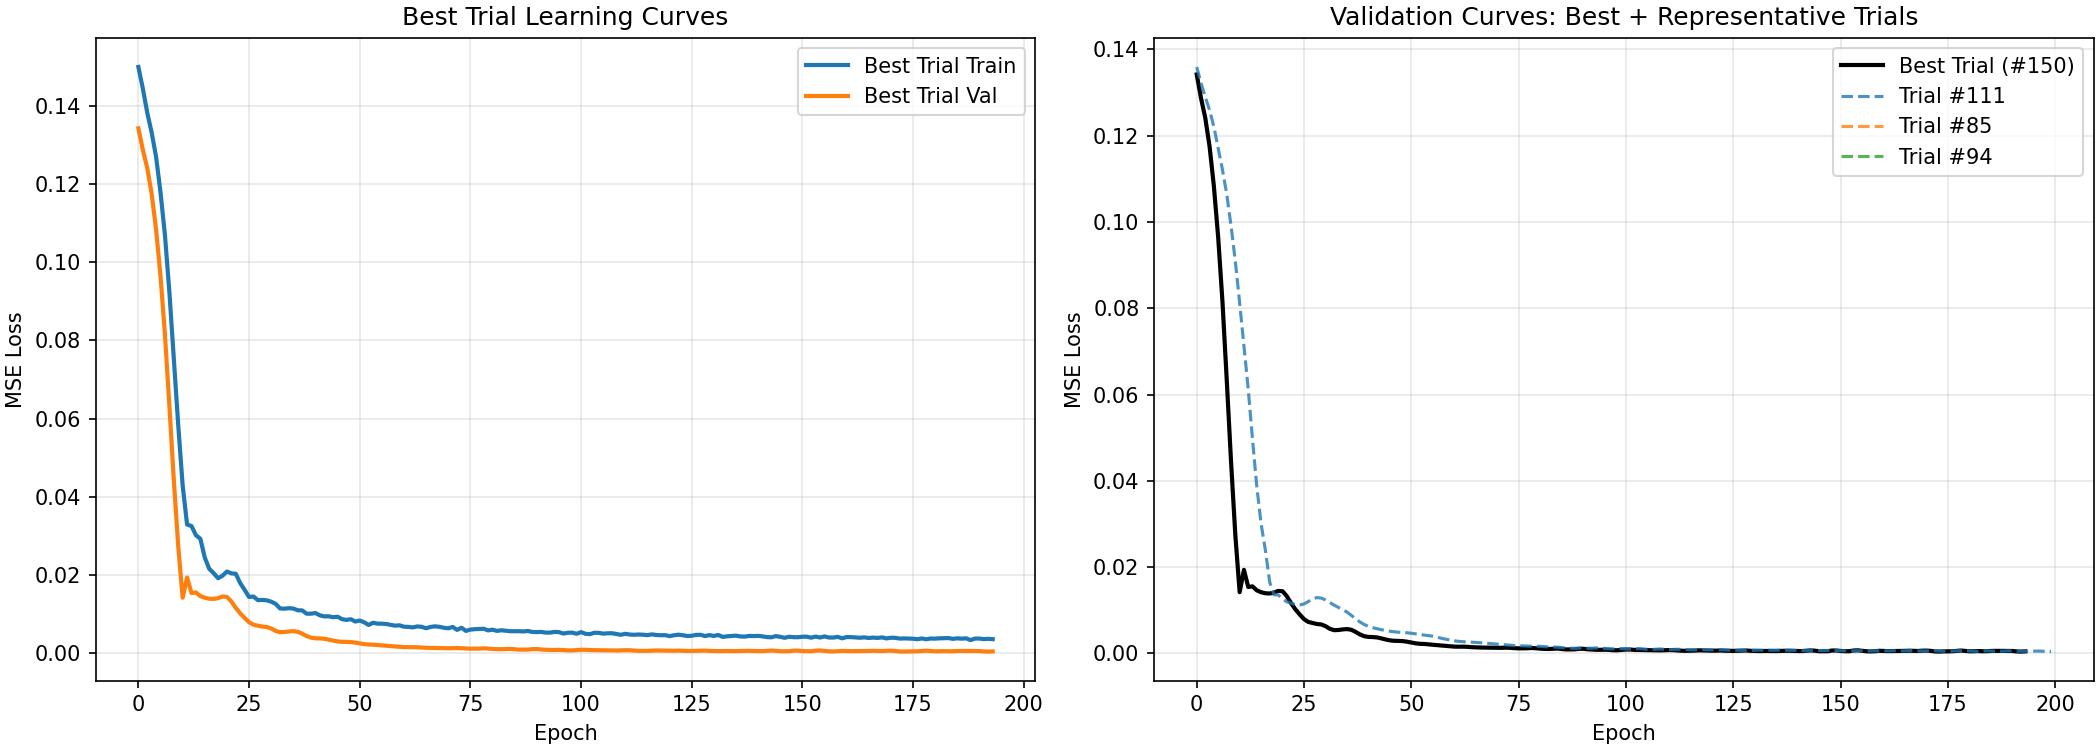

In [7]:
# Optimize the model hyperparameters using Optuna
best_model_path = Path(data_path) / "best_optimized_model.pt"
optimization_curves_path = Path(data_path) / "optimization_curves.png"

optimization_result = optimize_emulator(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=200,
    n_trials=200,
    early_stopping_patience=20,
    early_stopping_min_delta=1e-5,
    min_epochs_before_stopping=30,
    best_model_path=best_model_path,
    training_curves_plot_path=optimization_curves_path,
    representative_trial_count=3,
 )
study = optimization_result.study
print("Best hyperparameters: ", optimization_result.best_params)
print("Best validation loss: ", optimization_result.best_value)
print("Best optimized model saved to:", optimization_result.best_model_path)
print("Optimization curves saved to:", optimization_result.training_curves_plot_path)

from IPython.display import Image, display
if optimization_result.training_curves_plot_path is not None:
    display(Image(filename=optimization_result.training_curves_plot_path))

In [10]:
# Evaluate the best optimised model on the test set
import torch

best_params = optimization_result.best_params
n_hidden_layers = int(best_params["n_hidden_layers"])
hidden_units = tuple(int(best_params[f"n_hidden_units_{i + 1}"]) for i in range(n_hidden_layers))
dropout_rates = tuple(float(best_params[f"dropout_rate_{i + 1}"]) for i in range(n_hidden_layers))
device = training_config.device

best_model = build_emulator(
    input_dim=X_test.shape[1],
    hidden_units=hidden_units,
    dropout_rates=dropout_rates,
    output_dim=y_test.shape[1],
    device=device,
)
best_model.load_state_dict(torch.load(optimization_result.best_model_path, map_location=device))
best_model.to(device)
best_model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)
    predictions = best_model(X_test_tensor)
    mse_loss = torch.nn.MSELoss()(predictions, y_test_tensor)
print(f"Test MSE of best optimized model: {mse_loss.item():.4f}")

Test MSE of best optimized model: 0.0013


### (c)

To do Bayesian analysis we first define priors on the four parameters and a prior on the noise fraction. The noise fraction spans several orders of magnitude, so suggest a log-uniform prior from $10^{-3}$ to $1$.

For parameters that span multiple orders of magnitude, use similar priors. Otherwise, use uniform priors from the lowest to the highest observed values.

In [26]:
# Import MCMC utilities from the package module
import numpy as np

from apb86_a1.mcmc import (
    build_parameter_priors,
    log_posterior,
    noise_prior_type,
    sample_initial_positions,
)


def print_prior_summary(prior_specs):
    print("Parameter bounds and selected priors:")
    for spec in prior_specs:
        span_orders = spec["span_orders"]
        span_text = "n/a" if not np.isfinite(span_orders) else f"{span_orders:.2f}"
        print(
            f"  param_{spec['index']}: min={spec['min']:.6g}, max={spec['max']:.6g}, "
            f"span_orders={span_text}, prior={spec['prior']}"
        )

In [27]:
from emcee import EnsembleSampler

# Build adaptive priors from training-parameter ranges.
prior_specs = build_parameter_priors(params_train, order_threshold=2.0)
print_prior_summary(prior_specs)
noise_bounds = (1e-3, 1.0)
print(f"Noise prior bounds: [{noise_bounds[0]:.1e}, {noise_bounds[1]:.1e}] ({noise_prior_type(noise_bounds)})")

# Run MCMC sampling using posterior = prior + emulator-based likelihood.
n_walkers = 50
n_dims = 5  # 4 astrophysical/cosmological parameters + 1 noise fraction
initial_pos = sample_initial_positions(n_walkers, prior_specs, noise_bounds)

sampler = EnsembleSampler(
    n_walkers,
    n_dims,
    log_posterior,
    args=(
        best_model,
        pca_results.pca_model,
        observations_spectrum,
        normalization_stats,
        prior_specs,
        noise_bounds,
    ),
)
sampler.run_mcmc(initial_pos, 20000, progress=True)

Parameter bounds and selected priors:
  param_0: min=0.100003, max=9.99913, span_orders=2.00, prior=uniform
  param_1: min=0.00100144, max=0.999614, span_orders=3.00, prior=log_uniform
  param_2: min=0.00100062, max=0.999796, span_orders=3.00, prior=log_uniform
  param_3: min=0.500054, max=0.99999, span_orders=0.30, prior=uniform
Noise prior bounds: [1.0e-03, 1.0e+00] (log_uniform)


100%|██████████| 20000/20000 [03:00<00:00, 111.04it/s]


State([[1.51975869e+00 3.79103531e-01 6.91442236e-02 9.59576600e-01
  1.06133533e-01]
 [2.79714846e+00 4.04333902e-03 8.52701496e-02 8.88192287e-01
  5.28927540e-03]
 [9.28740481e+00 6.06972688e-01 5.64730428e-01 7.04643611e-01
  9.58474074e-01]
 [1.82265935e+00 6.34135713e-03 8.25288709e-02 8.00054260e-01
  2.89416900e-02]
 [1.45216726e-01 4.97684691e-01 6.17836953e-02 9.63082483e-01
  5.21914667e-03]
 [2.24997347e+00 6.98999170e-01 8.33268676e-02 7.24356375e-01
  3.81448078e-02]
 [3.09043164e+00 1.66673646e-01 8.66150278e-02 8.94979866e-01
  1.70413350e-01]
 [3.60728183e+00 1.99069111e-03 8.63516908e-02 5.74335677e-01
  3.02465316e-03]
 [1.68347159e+00 1.03843692e-01 7.94678319e-02 7.32655661e-01
  3.31938058e-03]
 [2.40461988e+00 4.95622285e-02 7.88228543e-02 5.50327477e-01
  8.85923676e-03]
 [2.15625827e+00 4.20121433e-01 8.60964091e-02 6.06282634e-01
  9.41183562e-02]
 [3.00870968e+00 1.09669821e-02 8.28029216e-02 6.15781325e-01
  1.53501677e-01]
 [9.64663390e+00 9.30446905e-01 5.

In [29]:
# Get chains and compute parameter estimates
samples = sampler.get_chain(discard=4000, thin=10, flat=True)
parameter_estimates = np.mean(samples, axis=0)
print("Parameter estimates from MCMC sampling:")
print(f"Astrophysical/Cosmological parameters: {parameter_estimates[:4]}")
print(f"Noise fraction: {parameter_estimates[4]:.4f}")

Parameter estimates from MCMC sampling:
Astrophysical/Cosmological parameters: [2.66914096 0.12593614 0.13006137 0.74379451]
Noise fraction: 0.1308
